# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [59]:
!pip install python-dotenv
import pandas as pd

In [60]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv()

connection_url = URL.create(
    drivername='postgresql+psycopg2',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    port=int(os.getenv('DB_PORT')),
    database=os.getenv('DB_NAME'),
    query={'sslmode': 'require'}
)

engine = create_engine(connection_url)

TypeError: int() argument must be a string, a bytes-like object or a number, not 'NoneType'

In [3]:
query = '''
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (
        p.created_dt_msk::date
        - LAG(p.created_dt_msk::date) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_dt_msk::date
        )
    ) AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name

FROM afisha.purchases AS p

JOIN afisha.events AS e
    ON e.event_id = p.event_id

JOIN afisha.city AS c
    ON c.city_id = e.city_id

JOIN afisha.regions AS r
    ON r.region_id = c.region_id

CROSS JOIN set_config_precode

WHERE p.device_type_canonical IN ('mobile', 'desktop')
    AND e.event_type_main <> 'фильм'

ORDER BY p.user_id ASC
'''

In [4]:
df = pd.read_sql(query, con=engine)

In [5]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [6]:
df.shape

(290611, 14)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  region_name            290611 non-null  obje

In [8]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [9]:
print('Количество строк:', df.shape[0])
print('Количество столбцов:', df.shape[1])
print('Количество уникальных пользователей:', df['user_id'].nunique())
print('Количество уникальных заказов:', df['order_id'].nunique())

Количество строк: 290611
Количество столбцов: 14
Количество уникальных пользователей: 21933
Количество уникальных заказов: 290611


In [10]:
df.dtypes

user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
service_name                     object
event_type_main                  object
region_name                      object
city_name                        object
dtype: object

In [11]:
print('Минимальная дата заказа:', df['order_dt'].min())
print('Максимальная дата заказа:', df['order_dt'].max())

Минимальная дата заказа: 2024-06-01 00:00:00
Максимальная дата заказа: 2024-10-31 00:00:00


###### Промежуточный вывод

В результате SQL-запроса получен датафрейм из 290 611 строк и 14 столбцов. В выборке представлено 21 933 уникальных пользователя и 290 611 уникальных заказов. Таким образом, каждая строка соответствует отдельному заказу.

Данные охватывают период с 1 июня по 31 октября 2024 года.

Пропущенные значения присутствуют только в столбце `days_since_prev`: заполнено 268 678 значений из 290 611. Количество пропусков составляет 21 933 — столько же, сколько уникальных пользователей в выборке. Это объясняется тем, что для первого заказа каждого пользователя предыдущая покупка отсутствует.

Столбцы `order_dt` и `order_ts` уже имеют корректный тип `datetime64[ns]`. Количественные показатели `revenue`, `tickets_count` и `days_since_prev` представлены числовыми типами данных. На этапе предобработки необходимо проверить категориальные значения, распределения количественных признаков и наличие выбросов, а также привести выручку к единой валюте.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [16]:
tenge_df = pd.read_csv(
    'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
)

tenge_df['data'] = pd.to_datetime(tenge_df['data'])

display(tenge_df.head())

print('\nВалюты в основной таблице:')
print(df['currency_code'].value_counts())

print('\nНоминал курса:', tenge_df['nominal'].unique())
print('Код валюты:', tenge_df['cdx'].unique())

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt



Валюты в основной таблице:
rub    285542
kzt      5069
Name: currency_code, dtype: int64

Номинал курса: [100]
Код валюты: ['kzt']


In [17]:
# На случай повторного запуска ячейки
df = df.drop(columns=['nominal', 'curs'], errors='ignore')

tenge_rates = (
    tenge_df[['data', 'nominal', 'curs']]
    .rename(columns={'data': 'order_dt'})
)

df = df.merge(
    tenge_rates,
    on='order_dt',
    how='left'
)

# Для рублёвых заказов выручка остаётся без изменений
df['revenue_rub'] = df['revenue']

# Для заказов в тенге переводим выручку в рубли
kzt_mask = df['currency_code'] == 'kzt'

df.loc[kzt_mask, 'revenue_rub'] = (
    df.loc[kzt_mask, 'revenue']
    * df.loc[kzt_mask, 'curs']
    / df.loc[kzt_mask, 'nominal']
)

In [18]:
print('Количество строк после объединения:', len(df))

print(
    'Пропущенных курсов для KZT:',
    df.loc[df['currency_code'] == 'kzt', 'curs'].isna().sum()
)

print('\nПримеры пересчёта KZT:')
display(
    df.loc[
        df['currency_code'] == 'kzt',
        ['order_dt', 'revenue', 'curs', 'nominal', 'revenue_rub']
    ].head()
)

print('\nПримеры заказов в RUB:')
display(
    df.loc[
        df['currency_code'] == 'rub',
        ['revenue', 'revenue_rub']
    ].head()
)

df = df.drop(columns=['nominal', 'curs'])

print('\nСтолбец revenue_rub создан:')
display(df[['currency_code', 'revenue', 'revenue_rub']].head())

Количество строк после объединения: 290611
Пропущенных курсов для KZT: 0

Примеры пересчёта KZT:


,order_dt,revenue,curs,nominal,revenue_rub
70,2024-09-17,518.10,19.0125,100,98.503762
89,2024-09-02,347.18,18.9330,100,65.731589
96,2024-09-09,328.77,18.5991,100,61.148261
277,2024-06-11,22021.55,19.8928,100,4380.702898
460,2024-06-04,7397.66,19.9833,100,1478.296591



Примеры заказов в RUB:


,revenue,revenue_rub
0,1521.94,1521.94
1,289.45,289.45
2,1258.57,1258.57
3,8.49,8.49
4,1390.41,1390.41



Столбец revenue_rub создан:


,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [19]:
print('Размер датафрейма:', df.shape)
print('Количество полных дубликатов:', df.duplicated().sum())

print('\nПропущенные значения:')
display(
    df.isna()
      .sum()
      .to_frame('missing_count')
)

print('\nТипы данных:')
display(
    df.dtypes.to_frame('dtype')
)

Размер датафрейма: (290611, 15)
Количество полных дубликатов: 0

Пропущенные значения:


,missing_count
user_id,0
device_type_canonical,0
order_id,0
order_dt,0
order_ts,0
currency_code,0
revenue,0
tickets_count,0
days_since_prev,21933
event_id,0



Типы данных:


,dtype
user_id,object
device_type_canonical,object
order_id,int32
order_dt,datetime64[ns]
order_ts,datetime64[ns]
currency_code,object
revenue,float64
tickets_count,int8
days_since_prev,Int16
event_id,int32


In [20]:
categorical_cols = [
    'device_type_canonical',
    'currency_code',
    'service_name',
    'event_type_main',
    'region_name',
    'city_name'
]

# Убираем возможные лишние пробелы
for col in categorical_cols:
    df[col] = df[col].str.strip()

# Проверяем основные категории
for col in categorical_cols:
    print(f'\n{col}: {df[col].nunique()} уникальных значений')
    display(df[col].value_counts(dropna=False).head(15))

# Сокращаем размерность числовых типов
for col in ['order_id', 'event_id', 'tickets_count']:
    df[col] = pd.to_numeric(df[col], downcast='integer')

# days_since_prev содержит целое число дней и пропуски
df['days_since_prev'] = df['days_since_prev'].astype('Int16')

print('\nТипы после преобразования:')
display(
    df[
        ['order_id', 'event_id', 'tickets_count', 'days_since_prev']
    ].dtypes.to_frame('dtype')
)


device_type_canonical: 2 уникальных значений


mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64


currency_code: 2 уникальных значений


rub    285542
kzt      5069
Name: currency_code, dtype: int64


service_name: 36 уникальных значений


...

Каменевский регион         91058
Североярская область       44049
Широковская область        16457
Медовская область          13901
Озернинский край           10476
Светополянский округ        7607
Малиновоярский округ        6618
Речиновская область         6293
Солнечноземская область     6288
Яблоневская область         6181
Серебринская область        5610
Горицветская область        5166
Травяная область            5045
Лугоградская область        4701
Тепляковская область        4389
Name: region_name, dtype: int64


city_name: 352 уникальных значений


Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
Дальнесветск     6293
Глинополье       6196
Светополье       5993
Глиноград        5934
Лесоярич         5831
Озёрчане         4790
Островецк        4722
Кристалевск      4690
Родниковецк      4568
Горнодолинск     3926
Name: city_name, dtype: int64


Типы после преобразования:


,dtype
order_id,int32
event_id,int32
tickets_count,int8
days_since_prev,Int16


Основные статистики:


,revenue_rub,tickets_count,days_since_prev
count,290611.000000,290611.000000,268678.000000
mean,555.571987,2.754311,3.222381
std,875.498172,1.170620,11.350509
min,-90.760000,1.000000,0.000000
25%,113.970000,2.000000,0.000000
50%,351.140000,3.000000,0.000000
75%,802.050000,4.000000,1.000000
max,81174.540000,57.000000,148.000000


Отрицательная выручка: 381
Нулевая выручка: 5526

Перцентили revenue_rub:


0.50      351.140000
0.90     1294.770000
0.95     1630.650000
0.99     2628.421739
1.00    81174.540000
Name: revenue_rub, dtype: float64


Перцентили tickets_count:


0.50     3.0
0.90     4.0
0.95     5.0
0.99     6.0
1.00    57.0
Name: tickets_count, dtype: float64

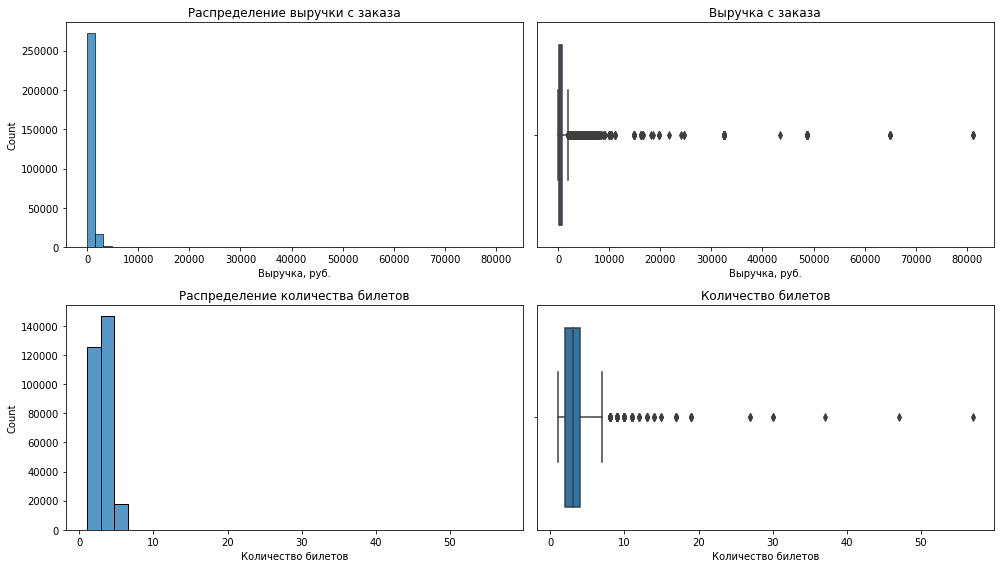

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Основные статистики:')
display(
    df[['revenue_rub', 'tickets_count', 'days_since_prev']]
    .describe()
)

print('Отрицательная выручка:',
      (df['revenue_rub'] < 0).sum())

print('Нулевая выручка:',
      (df['revenue_rub'] == 0).sum())

print('\nПерцентили revenue_rub:')
display(
    df['revenue_rub']
    .quantile([0.50, 0.90, 0.95, 0.99, 1.00])
)

print('\nПерцентили tickets_count:')
display(
    df['tickets_count']
    .quantile([0.50, 0.90, 0.95, 0.99, 1.00])
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['revenue_rub'], bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Распределение выручки с заказа')
axes[0, 0].set_xlabel('Выручка, руб.')

sns.boxplot(x=df['revenue_rub'], ax=axes[0, 1])
axes[0, 1].set_title('Выручка с заказа')
axes[0, 1].set_xlabel('Выручка, руб.')

sns.histplot(df['tickets_count'], bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Распределение количества билетов')
axes[1, 0].set_xlabel('Количество билетов')

sns.boxplot(x=df['tickets_count'], ax=axes[1, 1])
axes[1, 1].set_title('Количество билетов')
axes[1, 1].set_xlabel('Количество билетов')

plt.tight_layout()
plt.show()

In [22]:
rows_before = len(df)
users_before = df['user_id'].nunique()

# Удаляем некорректные отрицательные значения выручки
negative_revenue = (df['revenue_rub'] < 0).sum()
df = df[df['revenue_rub'] >= 0].copy()

# Фильтруем верхние выбросы по 99-му перцентилю
revenue_q99 = df['revenue_rub'].quantile(0.99)

df = df[
    df['revenue_rub'] <= revenue_q99
].copy()

# После удаления заказов пересчитываем интервал между покупками
df = df.sort_values(['user_id', 'order_ts']).copy()

df['days_since_prev'] = (
    df.groupby('user_id')['order_dt']
      .diff()
      .dt.days
      .astype('Int16')
)

rows_after = len(df)
users_after = df['user_id'].nunique()

removed_rows = rows_before - rows_after
removed_share = removed_rows / rows_before * 100

print(f'99-й перцентиль revenue_rub: {revenue_q99:.2f} руб.')
print('Отрицательных значений выручки:', negative_revenue)

print('\nСтрок до фильтрации:', rows_before)
print('Строк после фильтрации:', rows_after)
print('Удалено строк:', removed_rows)
print(f'Доля удалённых строк: {removed_share:.2f}%')

print('\nПользователей до фильтрации:', users_before)
print('Пользователей после фильтрации:', users_after)

print('\nСтатистика после обработки:')
display(
    df[['revenue_rub', 'tickets_count', 'days_since_prev']]
    .describe()
)

print('\nПропуски после обработки:')
display(
    df.isna()
      .sum()
      .to_frame('missing_count')
)

99-й перцентиль revenue_rub: 2628.42 руб.
Отрицательных значений выручки: 381

Строк до фильтрации: 290611
Строк после фильтрации: 287405
Удалено строк: 3206
Доля удалённых строк: 1.10%

Пользователей до фильтрации: 21933
Пользователей после фильтрации: 21838

Статистика после обработки:


,revenue_rub,tickets_count,days_since_prev
count,287405.000000,287405.000000,265567.000000
mean,518.719256,2.741323,3.239002
std,511.951842,1.163087,11.376576
min,0.000000,1.000000,0.000000
25%,112.600000,2.000000,0.000000
50%,344.830000,3.000000,0.000000
75%,788.900000,3.000000,1.000000
max,2628.421739,57.000000,148.000000



Пропуски после обработки:


,missing_count
user_id,0
device_type_canonical,0
order_id,0
order_dt,0
order_ts,0
currency_code,0
revenue,0
tickets_count,0
days_since_prev,21838
event_id,0


###### Промежуточный вывод

В ходе предобработки были проверены пропуски, дубликаты, типы данных и значения в основных столбцах. Полных дубликатов не обнаружено. Пропуски есть только в `days_since_prev`, так как для первого заказа пользователя предыдущей покупки ещё нет.

Даты уже были сохранены в правильном формате. Для части числовых столбцов размерность типов была уменьшена. Также были проверены категориальные признаки и их основные значения.

В `revenue_rub` обнаружились отрицательные значения и сильные выбросы. Было найдено 381 отрицательное значение, их удалили. Верхние выбросы также были отфильтрованы по 99-му перцентилю — 2628,42 руб.

Всего после обработки было удалено 3206 строк, или около 1,1% данных. В датасете осталось 287 405 заказов. По количеству билетов встречаются отдельные большие значения, но они могут относиться к групповым покупкам, поэтому их решили оставить.

После фильтрации `days_since_prev` был пересчитан, чтобы интервалы соответствовали оставшимся заказам. Данные готовы для дальнейшего анализа.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [23]:
# Сортируем заказы по пользователю и времени покупки
df = df.sort_values(['user_id', 'order_ts']).copy()

user_profile = (
    df.groupby('user_id', as_index=False)
      .agg(
          first_order_dt=('order_dt', 'first'),
          last_order_dt=('order_dt', 'last'),
          first_device=('device_type_canonical', 'first'),
          first_region=('region_name', 'first'),
          first_service=('service_name', 'first'),
          first_event_type=('event_type_main', 'first'),
          total_orders=('order_id', 'nunique'),
          avg_revenue_rub=('revenue_rub', 'mean'),
          avg_tickets_count=('tickets_count', 'mean'),
          avg_days_since_prev=('days_since_prev', 'mean')
      )
)

user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0


In [24]:
user_profile['is_two'] = (
    user_profile['total_orders'] >= 2
).astype(int)

user_profile['is_five'] = (
    user_profile['total_orders'] >= 5
).astype(int)

display(user_profile.head())

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


In [25]:
print('Размер профиля:', user_profile.shape)
print(
    'Количество уникальных пользователей:',
    user_profile['user_id'].nunique()
)

print('\nПропущенные значения:')
display(
    user_profile.isna()
                .sum()
                .to_frame('missing_count')
)

print('\nТипы данных:')
display(
    user_profile.dtypes.to_frame('dtype')
)

display(user_profile.head())

Размер профиля: (21838, 13)
Количество уникальных пользователей: 21838

Пропущенные значения:


,missing_count
user_id,0
first_order_dt,0
last_order_dt,0
first_device,0
first_region,0
first_service,0
first_event_type,0
total_orders,0
avg_revenue_rub,0
avg_tickets_count,0



Типы данных:


,dtype
user_id,object
first_order_dt,datetime64[ns]
last_order_dt,datetime64[ns]
first_device,object
first_region,object
first_service,object
first_event_type,object
total_orders,int64
avg_revenue_rub,float64
avg_tickets_count,float64


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [26]:
print('Количество пользователей:', len(user_profile))
print('Средняя выручка с заказа:',
      round(user_profile['avg_revenue_rub'].mean(), 2), 'руб.')

print('Доля пользователей с 2+ заказами:',
      round(user_profile['is_two'].mean() * 100, 2), '%')

print('Доля пользователей с 5+ заказами:',
      round(user_profile['is_five'].mean() * 100, 2), '%')

print('\nОсновные статистики:')
display(
    user_profile[
        ['total_orders', 'avg_tickets_count', 'avg_days_since_prev']
    ].describe()
)

print('\nПерцентили количества заказов:')
display(
    user_profile['total_orders']
    .quantile([0.50, 0.90, 0.95, 0.99, 1.00])
)

print('\nПерцентили среднего количества билетов:')
display(
    user_profile['avg_tickets_count']
    .quantile([0.50, 0.90, 0.95, 0.99, 1.00])
)

Количество пользователей: 21838
Средняя выручка с заказа: 545.03 руб.
Доля пользователей с 2+ заказами: 61.7 %
Доля пользователей с 5+ заказами: 29.0 %

Основные статистики:


,total_orders,avg_tickets_count,avg_days_since_prev
count,21838.000000,21838.000000,13475.000000
mean,13.160775,2.744062,15.899769
std,121.577370,0.913083,22.302167
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.083333
75%,5.000000,3.080000,20.500000
max,10168.000000,11.000000,148.000000



Перцентили количества заказов:


0.50        2.0
0.90       15.0
0.95       31.0
0.99      152.0
1.00    10168.0
Name: total_orders, dtype: float64


Перцентили среднего количества билетов:


0.50     2.75
0.90     4.00
0.95     4.00
0.99     5.00
1.00    11.00
Name: avg_tickets_count, dtype: float64

In [27]:
orders_q99 = user_profile['total_orders'].quantile(0.99)

users_before = len(user_profile)

user_profile = user_profile[
    user_profile['total_orders'] <= orders_q99
].copy()

users_after = len(user_profile)
removed_users = users_before - users_after
removed_share = removed_users / users_before * 100

print(f'99-й перцентиль количества заказов: {orders_q99:.0f}')
print('Пользователей до фильтрации:', users_before)
print('Пользователей после фильтрации:', users_after)
print('Удалено пользователей:', removed_users)
print(f'Доля удалённых пользователей: {removed_share:.2f}%')

print('\nСтатистика после фильтрации:')
display(
    user_profile[
        ['total_orders', 'avg_tickets_count', 'avg_days_since_prev']
    ].describe()
)

99-й перцентиль количества заказов: 152
Пользователей до фильтрации: 21838
Пользователей после фильтрации: 21622
Удалено пользователей: 216
Доля удалённых пользователей: 0.99%

Статистика после фильтрации:


,total_orders,avg_tickets_count,avg_days_since_prev
count,21622.000000,21622.000000,13259.000000
mean,6.496624,2.744256,16.151222
std,14.310784,0.917491,22.395180
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.357143
50%,2.000000,2.750000,8.466667
75%,5.000000,3.100000,21.000000
max,152.000000,11.000000,148.000000


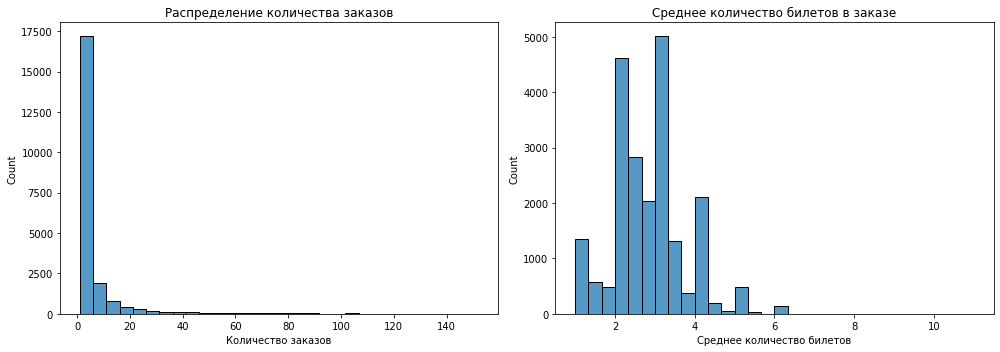

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    user_profile['total_orders'],
    bins=30,
    ax=axes[0]
)
axes[0].set_title('Распределение количества заказов')
axes[0].set_xlabel('Количество заказов')

sns.histplot(
    user_profile['avg_tickets_count'],
    bins=30,
    ax=axes[1]
)
axes[1].set_title('Среднее количество билетов в заказе')
axes[1].set_xlabel('Среднее количество билетов')

plt.tight_layout()
plt.show()

###### Промежуточный вывод

В профиле изначально было 21 838 пользователей. Средняя выручка с заказа составила около 545 руб. Повторный заказ совершили 61,7% пользователей, а 5 и более заказов — 29%.

По количеству заказов обнаружились заметные выбросы. Медиана составляет 2 заказа, 99-й перцентиль — 152 заказа, при этом максимальное значение было значительно выше. Поэтому пользователей с количеством заказов выше 99-го перцентиля исключили из дальнейшего анализа.

В результате было удалено 216 пользователей, или 0,99% выборки. После фильтрации осталось 21 622 пользователя.

По среднему количеству билетов сильных аномалий не обнаружено: у 99% пользователей показатель не превышает 5 билетов, поэтому эти данные оставили без дополнительной фильтрации.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [29]:
def segment_stats(data, column):
    result = (
        data.groupby(column)
            .size()
            .reset_index(name='users')
            .sort_values('users', ascending=False)
    )

    result['share'] = (
        result['users'] / len(data) * 100
    ).round(2)

    return result

In [30]:
event_stats = segment_stats(
    user_profile,
    'first_event_type'
)

device_stats = segment_stats(
    user_profile,
    'first_device'
)

region_stats = segment_stats(
    user_profile,
    'first_region'
)

service_stats = segment_stats(
    user_profile,
    'first_service'
)

print('Тип первого мероприятия:')
display(event_stats)

print('\nУстройство первого заказа:')
display(device_stats)

print('\nТоп-10 регионов:')
display(region_stats.head(10))

print('\nТоп-10 билетных операторов:')
display(service_stats.head(10))

Тип первого мероприятия:


,first_event_type,users,share
2,концерты,9564,44.23
1,другое,5401,24.98
5,театр,4245,19.63
4,стендап,1110,5.13
3,спорт,794,3.67
0,выставки,413,1.91
6,ёлки,95,0.44



Устройство первого заказа:


,first_device,users,share
1,mobile,17906,82.81
0,desktop,3716,17.19



Топ-10 регионов:


,first_region,users,share
23,Каменевский регион,7086,32.77
60,Североярская область,3768,17.43
77,Широковская область,1223,5.66
45,Озернинский край,675,3.12
41,Малиновоярский округ,526,2.43
76,Шанырский регион,502,2.32
74,Травяная область,488,2.26
57,Светополянский округ,457,2.11
52,Речиновская область,440,2.03
78,Яблоневская область,411,1.90



Топ-10 билетных операторов:


,first_service,users,share
3,Билеты без проблем,5167,23.90
22,Мой билет,2970,13.74
19,Лови билет!,2812,13.01
4,Билеты в руки,2557,11.83
23,Облачко,2177,10.07
7,Весь в билетах,1286,5.95
20,Лучшие билеты,1182,5.47
24,Прачечная,583,2.70
17,Край билетов,454,2.10
12,Дом культуры,356,1.65


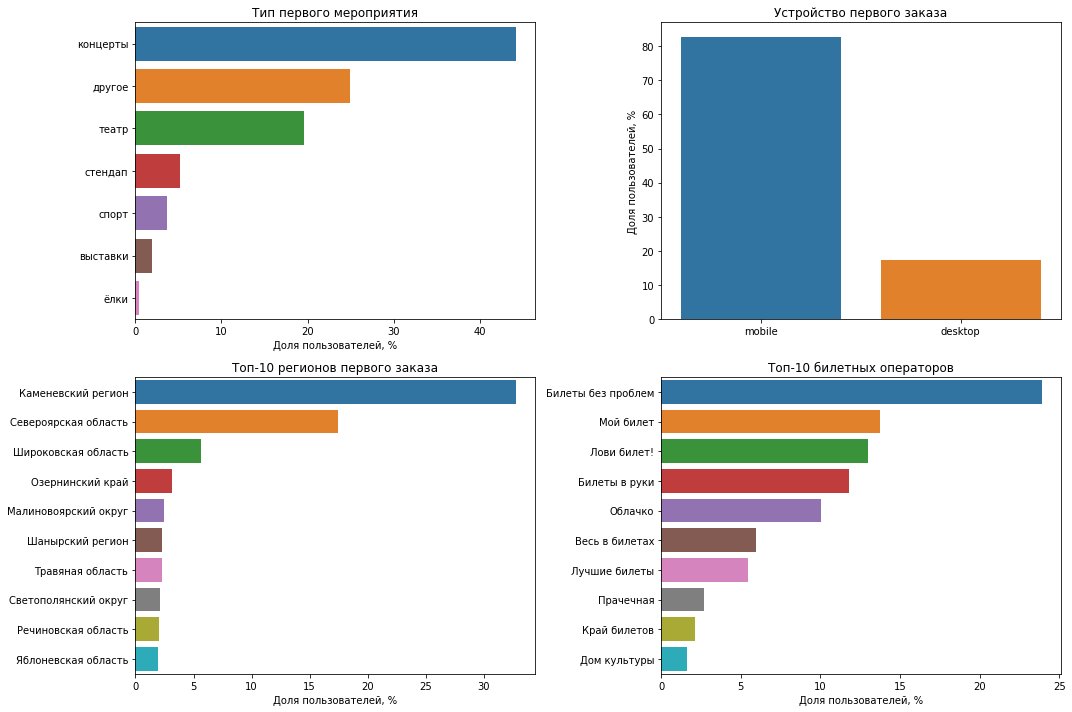

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(
    data=event_stats,
    x='share',
    y='first_event_type',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Тип первого мероприятия')
axes[0, 0].set_xlabel('Доля пользователей, %')
axes[0, 0].set_ylabel('')

sns.barplot(
    data=device_stats,
    x='first_device',
    y='share',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Устройство первого заказа')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Доля пользователей, %')

sns.barplot(
    data=region_stats.head(10),
    x='share',
    y='first_region',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Топ-10 регионов первого заказа')
axes[1, 0].set_xlabel('Доля пользователей, %')
axes[1, 0].set_ylabel('')

sns.barplot(
    data=service_stats.head(10),
    x='share',
    y='first_service',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Топ-10 билетных операторов')
axes[1, 1].set_xlabel('Доля пользователей, %')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

###### Промежуточный вывод

Пользователи распределены по сегментам неравномерно, поэтому можно выделить несколько основных точек входа.

Чаще всего первым мероприятием становятся концерты — 44,23% пользователей. Далее идут категория «другое» — 24,98% и театр — 19,63%. Остальные типы мероприятий встречаются заметно реже.

Большинство пользователей совершают первый заказ с мобильного устройства — 82,81%, тогда как на desktop приходится только 17,19%.

Среди регионов особенно выделяется Каменевский регион — 32,77% первых заказов. На втором месте Североярская область — 17,43%. Среди билетных операторов чаще всего первый заказ совершается через «Билеты без проблем» — 23,9%.

Таким образом, самые заметные точки входа — мобильные устройства, концерты, Каменевский регион и оператор «Билеты без проблем».

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [32]:
overall_return_rate = user_profile['is_two'].mean() * 100

def return_stats(data, column):
    result = (
        data.groupby(column)
            .agg(
                users=('user_id', 'nunique'),
                return_rate=('is_two', 'mean')
            )
            .reset_index()
    )

    result['return_rate'] = (
        result['return_rate'] * 100
    ).round(2)

    return result.sort_values(
        'return_rate',
        ascending=False
    )

print(
    'Средняя доля возврата по выборке:',
    round(overall_return_rate, 2),
    '%'
)

Средняя доля возврата по выборке: 61.32 %


In [33]:
event_return = return_stats(
    user_profile,
    'first_event_type'
)

device_return = return_stats(
    user_profile,
    'first_device'
)

region_return = return_stats(
    user_profile,
    'first_region'
)

service_return = return_stats(
    user_profile,
    'first_service'
)

print('Возврат по типу первого мероприятия:')
display(event_return)

print('\nВозврат по устройству:')
display(device_return)

print('\nТоп-10 регионов по числу пользователей:')
display(
    region_return
    .sort_values('users', ascending=False)
    .head(10)
)

print('\nТоп-10 операторов по числу пользователей:')
display(
    service_return
    .sort_values('users', ascending=False)
    .head(10)
)

Возврат по типу первого мероприятия:


,first_event_type,users,return_rate
0,выставки,413,64.16
5,театр,4245,63.44
2,концерты,9564,61.82
4,стендап,1110,60.90
1,другое,5401,59.56
3,спорт,794,55.79
6,ёлки,95,55.79



Возврат по устройству:


,first_device,users,return_rate
0,desktop,3716,63.83
1,mobile,17906,60.80



Топ-10 регионов по числу пользователей:


,first_region,users,return_rate
23,Каменевский регион,7086,62.39
60,Североярская область,3768,63.83
77,Широковская область,1223,64.43
45,Озернинский край,675,55.26
41,Малиновоярский округ,526,55.89
76,Шанырский регион,502,67.33
74,Травяная область,488,61.48
57,Светополянский округ,457,65.65
52,Речиновская область,440,63.41
78,Яблоневская область,411,59.37



Топ-10 операторов по числу пользователей:


,first_service,users,return_rate
3,Билеты без проблем,5167,60.33
22,Мой билет,2970,60.88
19,Лови билет!,2812,60.95
4,Билеты в руки,2557,62.77
23,Облачко,2177,61.23
7,Весь в билетах,1286,62.91
20,Лучшие билеты,1182,61.34
24,Прачечная,583,62.61
17,Край билетов,454,65.20
12,Дом культуры,356,64.61


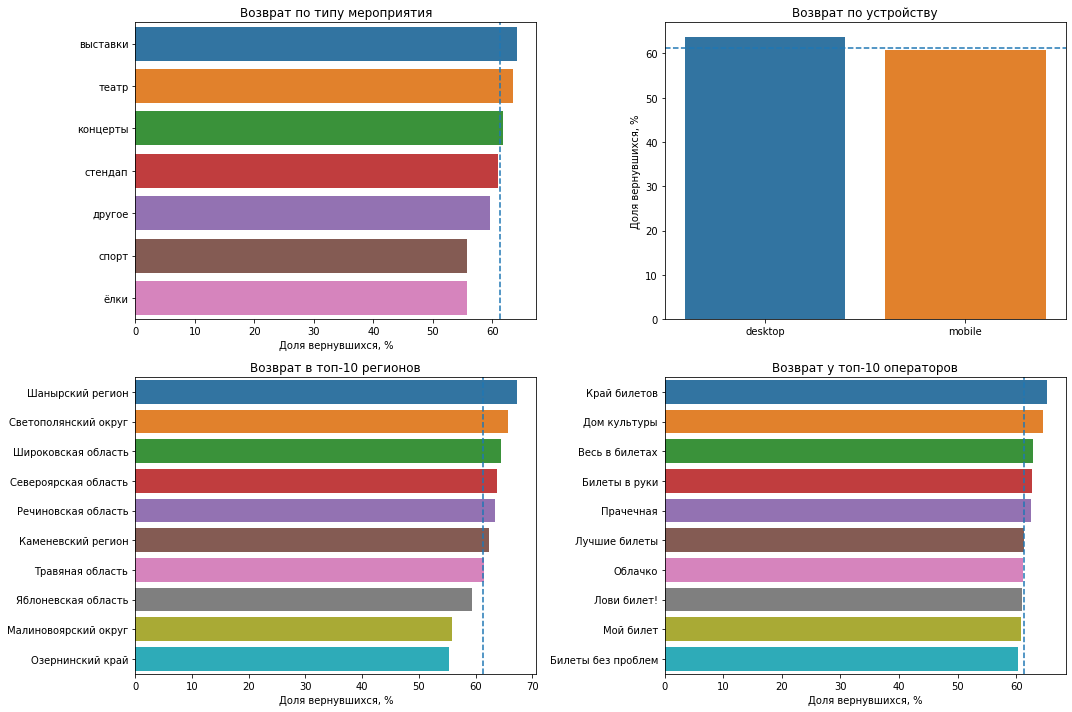

In [34]:
region_top10 = (
    region_return
    .sort_values('users', ascending=False)
    .head(10)
    .sort_values('return_rate', ascending=False)
)

service_top10 = (
    service_return
    .sort_values('users', ascending=False)
    .head(10)
    .sort_values('return_rate', ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(
    data=event_return,
    x='return_rate',
    y='first_event_type',
    ax=axes[0, 0]
)
axes[0, 0].axvline(
    overall_return_rate,
    linestyle='--'
)
axes[0, 0].set_title('Возврат по типу мероприятия')
axes[0, 0].set_xlabel('Доля вернувшихся, %')
axes[0, 0].set_ylabel('')

sns.barplot(
    data=device_return,
    x='first_device',
    y='return_rate',
    ax=axes[0, 1]
)
axes[0, 1].axhline(
    overall_return_rate,
    linestyle='--'
)
axes[0, 1].set_title('Возврат по устройству')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Доля вернувшихся, %')

sns.barplot(
    data=region_top10,
    x='return_rate',
    y='first_region',
    ax=axes[1, 0]
)
axes[1, 0].axvline(
    overall_return_rate,
    linestyle='--'
)
axes[1, 0].set_title('Возврат в топ-10 регионов')
axes[1, 0].set_xlabel('Доля вернувшихся, %')
axes[1, 0].set_ylabel('')

sns.barplot(
    data=service_top10,
    x='return_rate',
    y='first_service',
    ax=axes[1, 1]
)
axes[1, 1].axvline(
    overall_return_rate,
    linestyle='--'
)
axes[1, 1].set_title('Возврат у топ-10 операторов')
axes[1, 1].set_xlabel('Доля вернувшихся, %')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

###### Промежуточный вывод

Средняя доля пользователей, которые совершили повторный заказ, составляет около 61,3%.

По типу первого мероприятия чаще возвращаются пользователи, которые начинали с выставок — 64,16%, театра — 63,44% и концертов — 61,82%. При этом сегмент выставок небольшой, поэтому его результат стоит оценивать осторожнее. Самая низкая доля возврата среди крупных категорий наблюдается у спорта — 55,79%.

Пользователи, впервые оформившие заказ с desktop, возвращаются немного чаще — 63,83% против 60,8% у mobile.

Среди крупных регионов высокую долю возврата показывают Шанырский регион — 67,33%, Светополянский округ — 65,65% и Широковская область — 64,43%. Среди операторов выделяются «Край билетов» — 65,2% и «Дом культуры» — 64,61%.

При этом самые крупные точки входа не всегда дают самый высокий возврат. Например, оператор «Билеты без проблем» привлекает больше всего пользователей, но доля повторных заказов у него ниже среднего — 60,33%.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [35]:
hypothesis_1 = (
    user_profile[
        user_profile['first_event_type'].isin(['спорт', 'концерты'])
    ]
    .groupby('first_event_type')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
)

hypothesis_1['return_rate'] = (
    hypothesis_1['return_rate'] * 100
).round(2)

hypothesis_1

,users,return_rate
first_event_type,,
концерты,9564,61.82
спорт,794,55.79


In [37]:
import numpy as np
top_regions = (
    user_profile['first_region']
    .value_counts()
    .head(10)
    .index
)

user_profile['region_activity'] = np.where(
    user_profile['first_region'].isin(top_regions),
    'Топ-10 активных регионов',
    'Остальные регионы'
)

hypothesis_2 = (
    user_profile.groupby('region_activity')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
)

hypothesis_2['return_rate'] = (
    hypothesis_2['return_rate'] * 100
).round(2)

hypothesis_2

,users,return_rate
region_activity,,
Остальные регионы,6046,58.17
Топ-10 активных регионов,15576,62.54


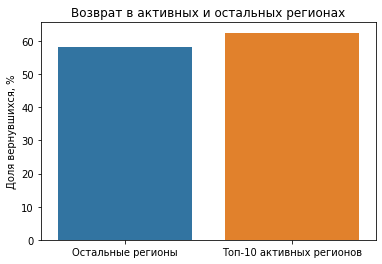

In [38]:
hypothesis_2_plot = (
    hypothesis_2
    .reset_index()
)

sns.barplot(
    data=hypothesis_2_plot,
    x='region_activity',
    y='return_rate'
)

plt.title('Возврат в активных и остальных регионах')
plt.xlabel('')
plt.ylabel('Доля вернувшихся, %')
plt.show()

###### Вывод по гипотезам

Первая гипотеза не подтвердилась. Пользователи, которые впервые покупали билеты на спортивные мероприятия, возвращались реже — 55,79%, чем пользователи, начавшие с концертов — 61,82%.

Вторая гипотеза подтвердилась. В топ-10 регионов с наибольшим количеством пользователей доля повторных заказов составила 62,54%, тогда как в остальных регионах — 58,17%.

Получается, что высокая активность региона действительно связана с более высокой долей повторных заказов, а спортивные мероприятия не являются более успешной точкой входа по сравнению с концертами.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [39]:
one_order = user_profile[
    user_profile['total_orders'] == 1
]['avg_revenue_rub']

returned = user_profile[
    user_profile['total_orders'] >= 2
]['avg_revenue_rub']

print('Пользователей с 1 заказом:', len(one_order))
print('Пользователей с 2+ заказами:', len(returned))

print('\nСредняя выручка:')
print('1 заказ:', round(one_order.mean(), 2), 'руб.')
print('2+ заказа:', round(returned.mean(), 2), 'руб.')

print('\nМедианная выручка:')
print('1 заказ:', round(one_order.median(), 2), 'руб.')
print('2+ заказа:', round(returned.median(), 2), 'руб.')

Пользователей с 1 заказом: 8363
Пользователей с 2+ заказами: 13259

Средняя выручка:
1 заказ: 545.77 руб.
2+ заказа: 545.07 руб.

Медианная выручка:
1 заказ: 378.87 руб.
2+ заказа: 496.54 руб.


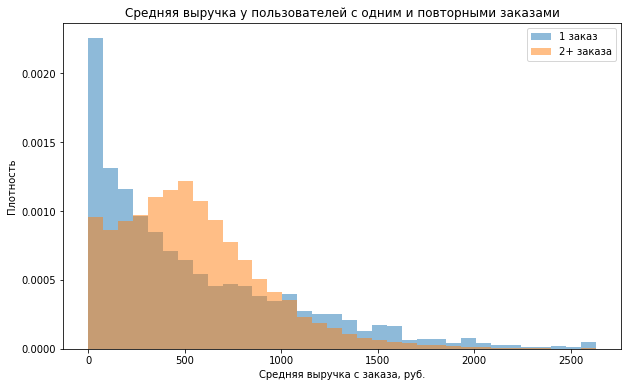

In [40]:
bins = np.linspace(
    user_profile['avg_revenue_rub'].min(),
    user_profile['avg_revenue_rub'].max(),
    35
)

plt.figure(figsize=(10, 6))

plt.hist(
    one_order,
    bins=bins,
    alpha=0.5,
    density=True,
    label='1 заказ'
)

plt.hist(
    returned,
    bins=bins,
    alpha=0.5,
    density=True,
    label='2+ заказа'
)

plt.title('Средняя выручка у пользователей с одним и повторными заказами')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()

plt.show()

In [41]:
revenue_compare = pd.DataFrame({
    '1 заказ': one_order.describe(),
    '2+ заказа': returned.describe()
})

display(revenue_compare)

,1 заказ,2+ заказа
count,8363.000000,13259.000000
mean,545.774764,545.070662
std,519.402525,369.285421
min,0.000000,0.000000
25%,133.055000,271.682500
50%,378.870000,496.543333
75%,830.975000,745.630577
max,2628.421739,2628.421739


###### Промежуточный вывод

Средняя выручка с заказа в двух группах почти одинаковая: около 546 руб. у пользователей с одним заказом и 545 руб. у пользователей с повторными заказами.

При этом медиана отличается сильнее. У пользователей с одним заказом она составляет около 379 руб., а у вернувшихся пользователей — около 497 руб. Значит, типичный заказ у вернувшихся пользователей несколько дороже.

В целом распределения похожи, поэтому явной связи между размером средней выручки и самим фактом повторной покупки не наблюдается. Однако у пользователей с повторными заказами значения больше сконцентрированы в среднем диапазоне, тогда как у пользователей с одним заказом разброс шире.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [42]:
orders_2_4 = user_profile[
    user_profile['total_orders'].between(2, 4)
]['avg_revenue_rub']

orders_5_plus = user_profile[
    user_profile['total_orders'] >= 5
]['avg_revenue_rub']

print('Пользователей с 2–4 заказами:', len(orders_2_4))
print('Пользователей с 5+ заказами:', len(orders_5_plus))

print('\nСредняя выручка:')
print('2–4 заказа:', round(orders_2_4.mean(), 2), 'руб.')
print('5+ заказов:', round(orders_5_plus.mean(), 2), 'руб.')

print('\nМедианная выручка:')
print('2–4 заказа:', round(orders_2_4.median(), 2), 'руб.')
print('5+ заказов:', round(orders_5_plus.median(), 2), 'руб.')

display(
    pd.DataFrame({
        '2–4 заказа': orders_2_4.describe(),
        '5+ заказов': orders_5_plus.describe()
    })
)

Пользователей с 2–4 заказами: 7143
Пользователей с 5+ заказами: 6116

Средняя выручка:
2–4 заказа: 552.32 руб.
5+ заказов: 536.61 руб.

Медианная выручка:
2–4 заказа: 472.47 руб.
5+ заказов: 513.31 руб.


,2–4 заказа,5+ заказов
count,7143.000000,6116.000000
mean,552.318951,536.605239
std,420.136847,298.957799
min,0.000000,0.000000
25%,219.565000,331.692137
50%,472.470000,513.309000
75%,799.257500,700.967911
max,2628.421739,2299.869022


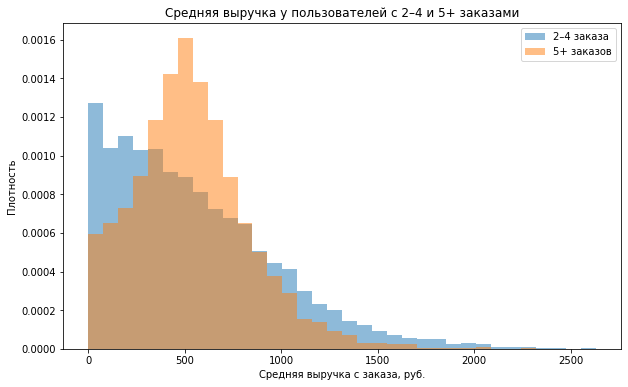

In [43]:
bins = np.linspace(
    user_profile['avg_revenue_rub'].min(),
    user_profile['avg_revenue_rub'].max(),
    35
)

plt.figure(figsize=(10, 6))

plt.hist(
    orders_2_4,
    bins=bins,
    alpha=0.5,
    density=True,
    label='2–4 заказа'
)

plt.hist(
    orders_5_plus,
    bins=bins,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.title('Средняя выручка у пользователей с 2–4 и 5+ заказами')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()

plt.show()

###### Промежуточный вывод

Средняя выручка у пользователей с 2–4 заказами немного выше — около 552 руб. против 537 руб. у пользователей с 5 и более заказами.

При этом медианная выручка, наоборот, выше у более активных пользователей: около 513 руб. против 472 руб. Также у группы с 5+ заказами разброс значений заметно меньше.

В целом сильной разницы между группами нет, но у пользователей с 5 и более заказами средняя выручка более стабильна и чаще находится в среднем диапазоне.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Основная статистика avg_tickets_count:


count    21622.000000
mean         2.744256
std          0.917491
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         11.000000
Name: avg_tickets_count, dtype: float64

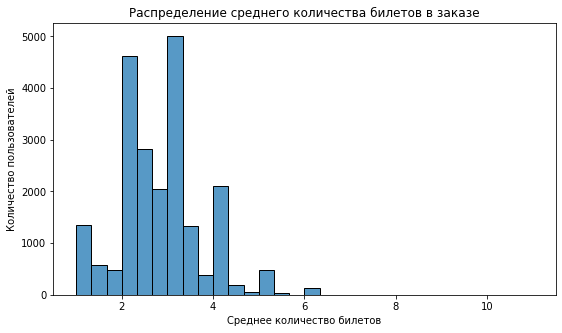

In [44]:
print('Основная статистика avg_tickets_count:')
display(user_profile['avg_tickets_count'].describe())

plt.figure(figsize=(9, 5))

sns.histplot(
    user_profile['avg_tickets_count'],
    bins=30
)

plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')

plt.show()

In [45]:
bins = [1, 2, 3, 5, float('inf')]
labels = [
    '1–2 билета',
    '2–3 билета',
    '3–5 билетов',
    '5+ билетов'
]

user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets_count'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

tickets_stats = (
    user_profile.groupby(
        'tickets_segment',
        observed=False
    )
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_stats['share'] = (
    tickets_stats['users'] / len(user_profile) * 100
).round(2)

tickets_stats['return_rate'] = (
    tickets_stats['return_rate'] * 100
).round(2)

tickets_stats

,tickets_segment,users,return_rate,share
0,1–2 билета,2410,51.24,11.15
1,2–3 билета,9487,73.56,43.88
2,3–5 билетов,9064,54.29,41.92
3,5+ билетов,661,18.76,3.06


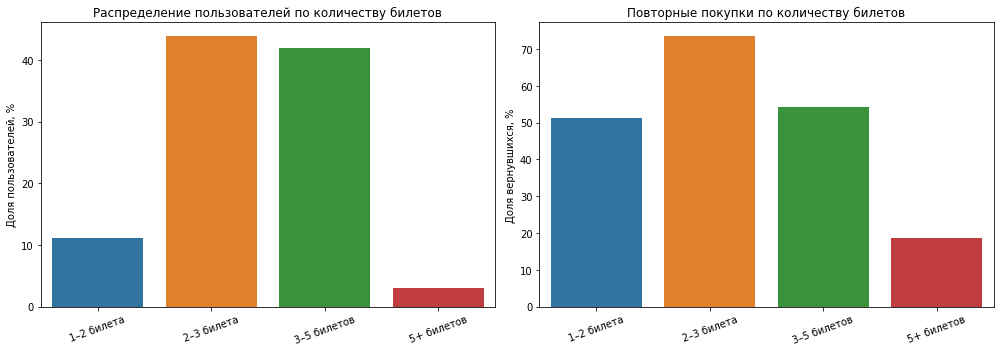

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=tickets_stats,
    x='tickets_segment',
    y='share',
    ax=axes[0]
)
axes[0].set_title('Распределение пользователей по количеству билетов')
axes[0].set_xlabel('')
axes[0].set_ylabel('Доля пользователей, %')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=tickets_stats,
    x='tickets_segment',
    y='return_rate',
    ax=axes[1]
)
axes[1].set_title('Повторные покупки по количеству билетов')
axes[1].set_xlabel('')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

###### Промежуточный вывод

Большинство пользователей сосредоточено в двух сегментах: со средним количеством 2–3 билета в заказе — 43,88% и 3–5 билетов — 41,92%.

Самая высокая доля повторных покупок наблюдается у пользователей, которые в среднем покупают 2–3 билета — 73,56%. В сегменте 3–5 билетов доля возврата заметно ниже и составляет 54,29%.

Сильнее всего выделяется сегмент 5+ билетов: в него входит только 3,06% пользователей, а доля повторных заказов составляет 18,76%. Получается, крупные по количеству билетов заказы чаще бывают разовыми.

Таким образом, наиболее лояльным выглядит сегмент пользователей, которые обычно покупают 2–3 билета за один заказ.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [47]:
weekday_order = [
    'Понедельник',
    'Вторник',
    'Среда',
    'Четверг',
    'Пятница',
    'Суббота',
    'Воскресенье'
]

weekday_map = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

user_profile['first_weekday'] = (
    user_profile['first_order_dt']
    .dt.dayofweek
    .map(weekday_map)
)

In [48]:
weekday_stats = (
    user_profile.groupby('first_weekday')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_stats['share'] = (
    weekday_stats['users'] / len(user_profile) * 100
).round(2)

weekday_stats['return_rate'] = (
    weekday_stats['return_rate'] * 100
).round(2)

weekday_stats

,first_weekday,users,return_rate,share
0,Понедельник,2918,62.99,13.50
1,Вторник,3175,61.89,14.68
2,Среда,3061,62.27,14.16
3,Четверг,3112,59.45,14.39
4,Пятница,3256,59.77,15.06
5,Суббота,3323,62.77,15.37
6,Воскресенье,2777,60.06,12.84


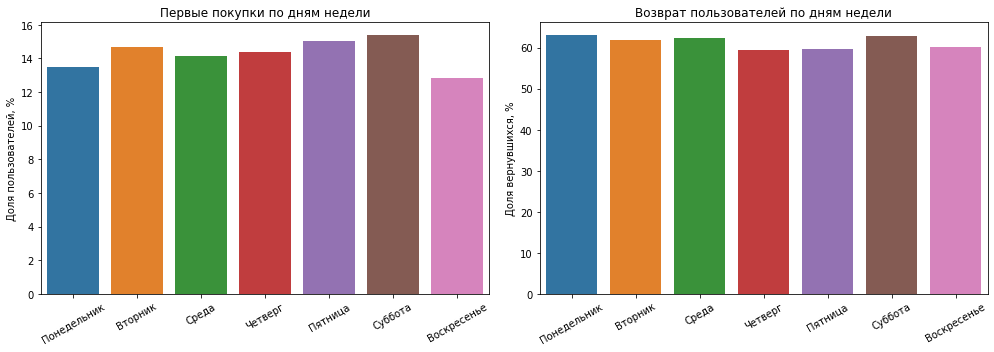

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=weekday_stats,
    x='first_weekday',
    y='share',
    ax=axes[0]
)
axes[0].set_title('Первые покупки по дням недели')
axes[0].set_xlabel('')
axes[0].set_ylabel('Доля пользователей, %')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(
    data=weekday_stats,
    x='first_weekday',
    y='return_rate',
    ax=axes[1]
)
axes[1].set_title('Возврат пользователей по дням недели')
axes[1].set_xlabel('')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

###### Промежуточный вывод

Распределение первых покупок по дням недели достаточно равномерное: на каждый день приходится примерно 13–15% пользователей.

Самая высокая доля повторных заказов наблюдается у пользователей, которые впервые купили билеты в понедельник — 62,99%, и в субботу — 62,77%. Самые низкие значения — в четверг (59,45%) и пятницу (59,77%).

Различия между днями недели небольшие, поэтому можно сделать вывод, что день первой покупки не оказывает сильного влияния на вероятность возврата пользователя.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [50]:
interval_2_4 = user_profile[
    user_profile['total_orders'].between(2, 4)
]['avg_days_since_prev']

interval_5_plus = user_profile[
    user_profile['total_orders'] >= 5
]['avg_days_since_prev']

print('Пользователей с 2–4 заказами:', interval_2_4.notna().sum())
print('Пользователей с 5+ заказами:', interval_5_plus.notna().sum())

print('\nСредний интервал между заказами:')
print('2–4 заказа:',
      round(interval_2_4.mean(), 2), 'дней')
print('5+ заказов:',
      round(interval_5_plus.mean(), 2), 'дней')

print('\nМедианный интервал:')
print('2–4 заказа:',
      round(interval_2_4.median(), 2), 'дней')
print('5+ заказов:',
      round(interval_5_plus.median(), 2), 'дней')

Пользователей с 2–4 заказами: 7143
Пользователей с 5+ заказами: 6116

Средний интервал между заказами:
2–4 заказа: 21.44 дней
5+ заказов: 9.97 дней

Медианный интервал:
2–4 заказа: 9.0 дней
5+ заказов: 8.21 дней


,2–4 заказа,5+ заказов
count,7143.000000,6116.000000
mean,21.440991,9.973194
std,28.594210,7.848293
min,0.000000,0.000000
25%,0.000000,3.919167
50%,9.000000,8.207143
75%,34.000000,14.250000
max,148.000000,37.500000


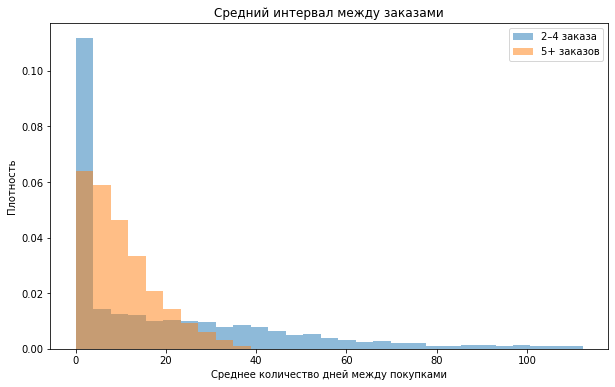

In [51]:
display(
    pd.DataFrame({
        '2–4 заказа': interval_2_4.describe(),
        '5+ заказов': interval_5_plus.describe()
    })
)

bins = np.linspace(
    0,
    user_profile['avg_days_since_prev'].dropna().quantile(0.99),
    30
)

plt.figure(figsize=(10, 6))

plt.hist(
    interval_2_4.dropna(),
    bins=bins,
    alpha=0.5,
    density=True,
    label='2–4 заказа'
)

plt.hist(
    interval_5_plus.dropna(),
    bins=bins,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.title('Средний интервал между заказами')
plt.xlabel('Среднее количество дней между покупками')
plt.ylabel('Плотность')
plt.legend()

plt.show()

###### Промежуточный вывод

Пользователи с 5 и более заказами совершают покупки заметно чаще. Средний интервал между их заказами составляет около 10 дней, тогда как у пользователей с 2–4 заказами — около 21 дня.

По медиане разница меньше: около 8 дней у пользователей с 5+ заказами и 9 дней у пользователей с 2–4 заказами. Большая разница именно в среднем значении связана с тем, что в группе 2–4 заказов встречаются длинные интервалы между покупками.

Таким образом, более активные пользователи в целом возвращаются за покупками быстрее и регулярнее.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [53]:
!pip install phik

     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01


In [54]:
import phik
from phik.report import plot_correlation_matrix

# Добавим лайфтайм пользователя
user_profile['lifetime_days'] = (
    user_profile['last_order_dt']
    - user_profile['first_order_dt']
).dt.days

correlation_cols = [
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'first_weekday',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_since_prev',
    'lifetime_days',
    'total_orders'
]

corr_data = user_profile[correlation_cols].copy()

corr_data.head()

,first_device,first_region,first_service,first_event_type,first_weekday,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,lifetime_days,total_orders
0,mobile,Каменевский регион,Край билетов,театр,Вторник,1521.940000,4.000000,<NA>,0,1
1,mobile,Каменевский регион,Мой билет,выставки,Вторник,774.010000,3.000000,75.0,75,2
2,mobile,Североярская область,Лови билет!,другое,Суббота,767.213333,2.666667,51.0,102,3
3,desktop,Каменевский регион,Край билетов,театр,Четверг,917.830000,4.000000,<NA>,0,1
4,mobile,Поленовский край,Лучшие билеты,театр,Воскресенье,61.310000,1.500000,16.0,16,2


Связь признаков с количеством заказов:


,phi_k
lifetime_days,0.615318
avg_days_since_prev,0.285242
avg_tickets_count,0.225326
avg_revenue_rub,0.219467
first_region,0.117162
first_weekday,0.059635
first_service,0.028571
first_event_type,0.028444
first_device,0.026483


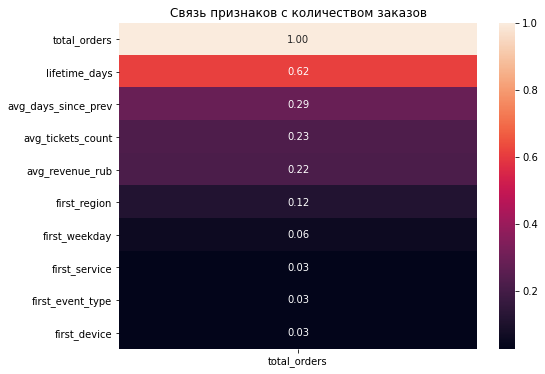

In [55]:
interval_cols = [
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_since_prev',
    'lifetime_days',
    'total_orders'
]

phik_matrix = corr_data.phik_matrix(
    interval_cols=interval_cols
)

total_orders_corr = (
    phik_matrix['total_orders']
    .drop('total_orders')
    .sort_values(ascending=False)
)

print('Связь признаков с количеством заказов:')
display(
    total_orders_corr.to_frame('phi_k')
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    phik_matrix[['total_orders']].sort_values(
        'total_orders',
        ascending=False
    ),
    annot=True,
    fmt='.2f'
)

plt.title('Связь признаков с количеством заказов')
plt.show()

In [56]:
user_profile['orders_group'] = pd.cut(
    user_profile['total_orders'],
    bins=[0, 1, 4, float('inf')],
    labels=[
        '1 заказ',
        '2–4 заказа',
        '5+ заказов'
    ]
)

segment_corr_cols = [
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'first_weekday',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_since_prev',
    'lifetime_days',
    'orders_group'
]

segment_corr_data = user_profile[
    segment_corr_cols
].copy()

segment_phik = segment_corr_data.phik_matrix(
    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev',
        'lifetime_days'
    ]
)

orders_group_corr = (
    segment_phik['orders_group']
    .drop('orders_group')
    .sort_values(ascending=False)
)

display(
    orders_group_corr.to_frame('phi_k')
)

,phi_k
lifetime_days,0.728494
avg_days_since_prev,0.388618
avg_tickets_count,0.383043
avg_revenue_rub,0.325259
first_region,0.123894
first_service,0.082321
first_event_type,0.041037
first_weekday,0.033205
first_device,0.017415


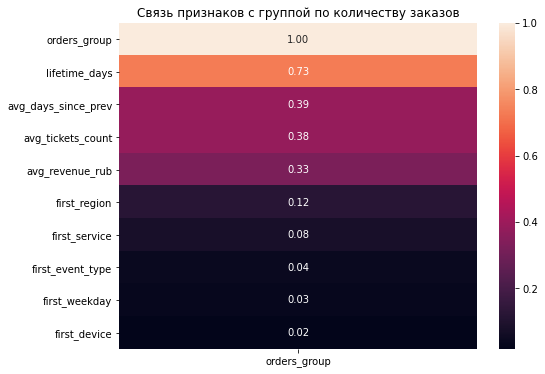

In [57]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    segment_phik[['orders_group']].sort_values(
        'orders_group',
        ascending=False
    ),
    annot=True,
    fmt='.2f'
)

plt.title('Связь признаков с группой по количеству заказов')
plt.show()

###### Промежуточный вывод

Корреляционный анализ показал, что сильнее всего с количеством заказов связан лайфтайм пользователя. Для `total_orders` коэффициент `phi_k` составил 0,62.

После разделения пользователей на группы «1 заказ», «2–4 заказа» и «5+ заказов» связь стала ещё заметнее: для `lifetime_days` коэффициент составил 0,73. Также выделяются средний интервал между заказами (`phi_k` = 0,39), среднее количество билетов (`phi_k` = 0,38) и средняя выручка (`phi_k` = 0,33).

Признаки первого заказа связаны с количеством покупок значительно слабее. Среди них немного выделяется регион первого заказа, но его коэффициент остаётся невысоким.

Таким образом, количество заказов сильнее связано с дальнейшим поведением пользователя и продолжительностью его активности, чем с характеристиками первой покупки.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

###### Общий вывод и рекомендации

В рамках проекта были проанализированы данные о заказах пользователей Яндекс Афиши за период с июня по октябрь 2024 года. Исходная выборка содержала 290 611 заказов. Выручка в тенге была переведена в рубли, после чего были проверены пропуски, типы данных и выбросы.

При предобработке были удалены отрицательные значения выручки и верхние выбросы выше 99-го перцентиля. Всего было исключено 3206 заказов, или около 1,1% исходных данных. После очистки осталось 287 405 заказов. При построении пользовательского профиля дополнительно были исключены 216 пользователей с аномально большим количеством заказов. Для дальнейшего анализа осталось 21 622 пользователя.

Около 61% пользователей совершили повторный заказ. Среди признаков первого заказа заметны несколько основных точек входа. Чаще всего пользователи начинали с концертов — 44,23%, а 82,81% первых покупок совершались с мобильных устройств. Крупнейшим регионом оказался Каменевский регион, а самым частым первым билетным оператором — «Билеты без проблем».

При этом самые крупные сегменты не всегда показывали самый высокий возврат. Например, пользователи, впервые купившие билеты на театр, возвращались чаще, чем пользователи концертов. Спортивные мероприятия показали более низкую долю возврата — 55,79%, поэтому гипотеза о том, что спортивные мероприятия лучше концертов удерживают пользователей, не подтвердилась.

Вторая гипотеза подтвердилась: в топ-10 наиболее активных регионов повторный заказ совершили 62,54% пользователей, а в остальных регионах — 58,17%.

Размер выручки сам по себе не показал сильной связи с возвратом. Средняя выручка у пользователей с одним заказом и у вернувшихся пользователей практически одинаковая — около 545 руб. При этом медианная выручка у вернувшихся пользователей немного выше.

Более заметная связь наблюдается с количеством билетов. Самая высокая доля повторных покупок — 73,56% — у пользователей, которые в среднем покупают 2–3 билета. У пользователей со средним заказом от 5 билетов доля возврата составила только 18,76%.

День недели первой покупки практически не влияет на дальнейший возврат: показатели по дням отличаются незначительно. При этом более активные пользователи возвращаются быстрее. У пользователей с 5 и более заказами средний интервал между покупками составляет около 10 дней, а у пользователей с 2–4 заказами — около 21 дня.

Корреляционный анализ показал, что сильнее всего с количеством заказов связан лайфтайм пользователя. Также заметна связь со средним интервалом между покупками, количеством билетов и средней выручкой. Характеристики первого заказа — устройство, тип мероприятия, оператор и день недели — связаны с количеством заказов значительно слабее.

###### Рекомендации

- В первую очередь стоит работать с пользователями, покупающими 2–3 билета: этот сегмент показывает самую высокую долю повторных покупок.
- Для мобильных пользователей можно усилить коммуникацию после первой покупки, так как это крупнейшая точка входа, но их возврат немного ниже, чем у пользователей desktop.
- В активных регионах имеет смысл продолжать удерживающие кампании, так как там доля возврата выше. В остальных регионах можно отдельно тестировать дополнительные механики повторных продаж.
- Пользователей спортивных мероприятий стоит рассматривать как отдельный сегмент и тестировать для них дополнительные рекомендации и предложения, так как сейчас они возвращаются реже пользователей концертов.
- Пользователей с крупными заказами на 5 и более билетов не стоит автоматически считать наиболее лояльными: такие заказы часто оказываются разовыми.
- Для наиболее активных клиентов можно тестировать повторные предложения в первые 1–2 недели после покупки, так как пользователи с большим числом заказов возвращаются заметно быстрее.
- При создании будущей модели прогнозирования возврата стоит учитывать поведенческие признаки, но важно помнить, что `lifetime_days` и средний интервал между заказами появляются уже после накопления истории покупок и не подходят для прогноза сразу после первого заказа.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**